# Notebook Incisos 3 y 4 - Laboratorio 10
*Este notebook contiene los incisos 3 y 4 (coorespondientes a la experimentación y visualización respectivamente) del Laboratorio 10 de Minería de Datos.*

## Configuración

**Librerías**

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.semi_supervised import SelfTrainingClassifier, LabelSpreading
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns
from sklearn.decomposition import PCA

## Preprocesamiento

Se tienen los dataframes para distintos porcentajes de etiquetas en los datos (5%, 10%, 20%)

In [48]:
df5train = pd.read_csv('train_5_porc.csv')
df5train

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,1.190931,-0.633681,-0.497692,0.382045,0,0,1,0,0,0
1,-1.156464,3.249031,2.098923,0.478736,0,1,1,0,1,0
2,-0.080013,-0.633681,-0.497692,-0.859250,0,1,1,0,1,0
3,-0.014386,-0.633681,-0.497692,-0.353367,1,0,0,0,1,1
4,0.579884,1.038512,-0.497692,1.548433,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
329,0.048854,-0.633681,-0.497692,0.986020,0,0,1,0,1,-1
330,-0.370504,-0.633681,1.140590,0.078301,1,0,0,0,1,-1
331,0.753919,-0.633681,-0.497692,-0.864595,0,1,1,0,1,-1
332,-0.014386,1.038512,1.140590,0.125453,0,1,0,0,1,-1


In [49]:
df10train = pd.read_csv('train_10_porc.csv')
df10train.head()

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,-0.148214,-0.633681,-0.497692,-0.353367,1,0,1,0,1,0
1,0.048854,-0.633681,-0.497692,-0.876361,0,1,0,1,0,1
2,1.190931,-0.633681,-0.497692,0.344365,0,0,0,0,0,1
3,0.048854,-0.633681,-0.497692,-0.939901,0,1,1,0,0,0
4,-0.080013,-0.633681,-0.497692,-0.859250,0,1,1,0,1,0


In [50]:
df20train = pd.read_csv('train_20_porc.csv')
df20train.head()

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,-0.219200,-0.633681,-0.497692,-0.870955,0,1,1,0,1,0
1,-0.719452,-0.633681,-0.497692,0.888262,0,0,1,0,1,0
2,-0.625434,-0.633681,-0.497692,-0.593383,1,0,1,0,1,0
3,-0.014386,-0.633681,-0.497692,-0.353367,1,0,0,0,1,1
4,0.048854,1.038512,4.944562,1.284875,0,1,0,0,1,1


In [51]:
#Dataframe de prueba
dftest = pd.read_csv('test.csv')
dftest

,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,0.334561,-0.633681,-0.497692,-0.389701,1,0,1,0,1,0
1,0.048854,1.038512,-0.497692,-1.044639,0,1,1,0,0,0
2,0.485866,-0.633681,-0.497692,-0.438927,1,0,1,1,0,0
3,-1.156464,-0.633681,2.098923,0.042386,0,1,1,0,1,0
4,1.513330,1.038512,-0.497692,1.365324,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
79,0.048854,-0.633681,-0.497692,-0.859250,0,1,1,0,1,0
80,-0.451398,-0.633681,-0.497692,-0.327799,1,0,1,0,0,0
81,0.109874,-0.633681,-0.497692,0.290353,1,0,1,0,1,0
82,0.986118,-0.633681,-0.497692,-0.593383,1,0,1,0,1,0


### Separación de datos

Se sigue el proceso hecho en el archivo de EDA

In [52]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [53]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [54]:
#Tratamiento de nulos
mediana_age = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana_age)
mediana_fare = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(mediana_fare)

In [55]:
#Se aplica una escala logarítmica
columnas = ['Age', 'SibSp', 'Parch', 'Fare']
for columna in columnas:
    df[columna] = np.log1p(df[columna])

In [56]:
scaler = StandardScaler()
df[columnas] = scaler.fit_transform(df[columnas])
columnas_categoricas = ['Pclass', 'Sex', 'Embarked']

df = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

In [57]:
df.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,0.461545,-0.633681,-0.497692,-0.867031,0,1,1,1,0
1,1,0.986118,1.038512,-0.497692,-0.969149,0,1,0,0,1
2,0,1.458985,-0.633681,-0.497692,-0.669252,1,0,1,1,0
3,0,0.048854,-0.633681,-0.497692,-0.773647,0,1,1,0,1
4,1,-0.293207,1.038512,1.140590,-0.443786,0,1,0,0,1


### Separación en Training y Test Set

In [58]:
target = 'Survived'
X = df.drop(columns=[target])
y = df[target]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

## Modelos

### TRANSDUCTIVE SVM 

In [60]:
C_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]
threshold_values = [0.6, 0.8, 0.95]

#### Para el 5%

In [61]:
y5train=df5train['Survived']
resultados1=[]
for C in C_values:
    for gamma in gamma_values:
        for threshold in threshold_values:
            
            base_svm5 = SVC(probability=True)
            
            modelo1 = SelfTrainingClassifier(
                base_svm5,
                threshold=threshold
            )
            
            modelo1.fit(X_train, y5train)
            
            y_pred5 = modelo1.predict(X_test)
            
            acc = accuracy_score(y_test, y_pred5)
            f1 = f1_score(y_test, y_pred5)
            
            resultados1.append({
                "C": C,
                "gamma": gamma,
                "threshold": threshold,
                "accuracy": acc,
                "f1": f1
            })

df_resultados5 = pd.DataFrame(resultados1)

In [62]:
df_resultados5

,C,gamma,threshold,accuracy,f1
0,0.1,0.01,0.60,0.630952,0.000000
1,0.1,0.01,0.80,0.630952,0.000000
2,0.1,0.01,0.95,0.666667,0.176471
3,0.1,0.10,0.60,0.214286,0.108108
4,0.1,0.10,0.80,0.630952,0.000000
5,0.1,0.10,0.95,0.666667,0.176471
6,0.1,1.00,0.60,0.630952,0.000000
7,0.1,1.00,0.80,0.630952,0.000000
8,0.1,1.00,0.95,0.666667,0.176471
9,1.0,0.01,0.60,0.238095,0.058824


In [63]:
df_resultados5["score"] = (
    0.7 * df_resultados5["f1"] +
    0.3 * df_resultados5["accuracy"]
)

mejor5 = df_resultados5.loc[
    df_resultados5["score"].idxmax()
]

In [64]:
print("==Mejor modelo==")
print(mejor5)

==Mejor modelo==
C            1.000000
gamma        1.000000
threshold    0.600000
accuracy     0.666667
f1           0.222222
score        0.355556
Name: 15, dtype: float64


In [65]:
cm = confusion_matrix(y_test, y_pred5)
cm

array([[53,  0],
       [31,  0]], dtype=int64)

Se observa que este modelo, a pesar que es el mejor modelo, este es bastante deficiente en la clasificación, ya que solo ha clasificado correctamente 53 elementos, y el resto ha sido herrado (31  elementos). Cabe decir que de los que ha clasificado correctamente, todos son solamente de un tipo.

#### Para el 10%

In [66]:
y10train=df10train['Survived']
resultados2=[]
for C in C_values:
    for gamma in gamma_values:
        for threshold in threshold_values:
            
            base_svm10 = SVC(probability=True)
            
            modelo2 = SelfTrainingClassifier(
                base_svm10,
                threshold=threshold
            )
            
            modelo2.fit(X_train, y10train)
            
            y_pred10 = modelo2.predict(X_test)
            
            acc = accuracy_score(y_test, y_pred10)
            f1 = f1_score(y_test, y_pred10)
            
            resultados2.append({
                "C": C,
                "gamma": gamma,
                "threshold": threshold,
                "accuracy": acc,
                "f1": f1
            })

df_resultados10 = pd.DataFrame(resultados2)

In [67]:
df_resultados10

,C,gamma,threshold,accuracy,f1
0,0.1,0.01,0.60,0.630952,0.0
1,0.1,0.01,0.80,0.714286,0.4
2,0.1,0.01,0.95,0.714286,0.4
3,0.1,0.10,0.60,0.630952,0.0
4,0.1,0.10,0.80,0.630952,0.0
5,0.1,0.10,0.95,0.714286,0.4
6,0.1,1.00,0.60,0.630952,0.0
7,0.1,1.00,0.80,0.630952,0.0
8,0.1,1.00,0.95,0.714286,0.4
9,1.0,0.01,0.60,0.630952,0.0


In [68]:
df_resultados10["score"] = (
    0.7 * df_resultados10["f1"] +
    0.3 * df_resultados10["accuracy"]
)

mejor10 = df_resultados10.loc[
    df_resultados5["score"].idxmax()
]
print(mejor10)

C            1.000000
gamma        1.000000
threshold    0.600000
accuracy     0.630952
f1           0.000000
score        0.189286
Name: 15, dtype: float64


In [69]:
cm2 = confusion_matrix(y_test, y_pred10)
cm2

array([[52,  1],
       [23,  8]], dtype=int64)

Es posible observar que este modelo no resulta ser un buen clasificador, aunque es mejor que el anterior. Esto es porque ahora ya clasifica correctamente de los dos tipos, y estos siguen siendo mayores que los casos errados. Aún así, no resulta ser un buen modelo.

#### Para el 20%

In [70]:
y20train=df20train['Survived']
resultados3=[]
for C in C_values:
    for gamma in gamma_values:
        for threshold in threshold_values:
            
            base_svm20 = SVC(probability=True)
            
            modelo3 = SelfTrainingClassifier(
                base_svm20,
                threshold=threshold
            )
            
            modelo3.fit(X_train, y20train)
            
            y_pred20 = modelo3.predict(X_test)
            
            acc = accuracy_score(y_test, y_pred20)
            f1 = f1_score(y_test, y_pred20)
            
            resultados3.append({
                "C": C,
                "gamma": gamma,
                "threshold": threshold,
                "accuracy": acc,
                "f1": f1
            })

df_resultados20 = pd.DataFrame(resultados3)

In [71]:
df_resultados20

,C,gamma,threshold,accuracy,f1
0,0.1,0.01,0.60,0.630952,0.000000
1,0.1,0.01,0.80,0.738095,0.450000
2,0.1,0.01,0.95,0.738095,0.450000
3,0.1,0.10,0.60,0.630952,0.000000
4,0.1,0.10,0.80,0.738095,0.450000
5,0.1,0.10,0.95,0.738095,0.450000
6,0.1,1.00,0.60,0.630952,0.060606
7,0.1,1.00,0.80,0.738095,0.450000
8,0.1,1.00,0.95,0.738095,0.450000
9,1.0,0.01,0.60,0.750000,0.511628


In [72]:
df_resultados20["score"] = (
    0.7 * df_resultados20["f1"] +
    0.3 * df_resultados20["accuracy"]
)

mejor20 = df_resultados20.loc[
    df_resultados20["score"].idxmax()
]
print(mejor20)

C            10.000000
gamma         1.000000
threshold     0.600000
accuracy      0.761905
f1            0.545455
score         0.610390
Name: 24, dtype: float64


In [73]:

cm3 = confusion_matrix(y_test, y_pred20)
cm3

array([[53,  0],
       [22,  9]], dtype=int64)

Se observa que este tampoco es un buen modelo de clasificación.

### LAPLACIAN SVM

#### Para el 5%

In [74]:
resultados5_lap = []

gamma_values = [0.01, 0.1, 1]
alpha_values = [0.2, 0.5, 0.8]

for gamma in gamma_values:
    for alpha in alpha_values:
        
        modelo5_lap = LabelSpreading(
            kernel='rbf',
            gamma=gamma,
            alpha=alpha,
            max_iter=100
        )
        
        modelo5_lap.fit(X_train, y5train)
        
        ypred5_lap = modelo5_lap.predict(X_test)
        
        acc = accuracy_score(y_test, ypred5_lap)
        f1 = f1_score(y_test, ypred5_lap)
        
        resultados5_lap.append({
            "gamma": gamma,
            "alpha": alpha,
            "accuracy": acc,
            "f1": f1
        })

df_resultados5_lap = pd.DataFrame(resultados5_lap)

In [75]:
df_resultados5_lap

,gamma,alpha,accuracy,f1
0,0.01,0.2,0.630952,0.000000
1,0.01,0.5,0.630952,0.000000
2,0.01,0.8,0.630952,0.000000
3,0.10,0.2,0.630952,0.000000
4,0.10,0.5,0.630952,0.000000
5,0.10,0.8,0.630952,0.000000
6,1.00,0.2,0.785714,0.640000
7,1.00,0.5,0.761905,0.583333
8,1.00,0.8,0.761905,0.565217


In [76]:
mejor5_lap = df_resultados5_lap.loc[
    (
        0.7 * df_resultados5_lap["f1"] +
        0.3 * df_resultados5_lap["accuracy"]
    ).idxmax()
]

print(mejor5_lap)

gamma       1.000000
alpha       0.200000
accuracy    0.785714
f1          0.640000
Name: 6, dtype: float64


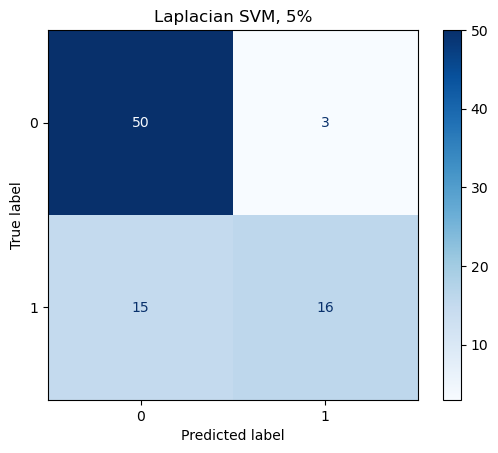

In [77]:
best_model5 = LabelSpreading(
    kernel='rbf',
    gamma=mejor5_lap["gamma"],
    alpha=mejor5_lap["alpha"]
)

best_model5.fit(X_train, y5train)

y_pred_best5 = best_model5.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best5)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Laplacian SVM, 5%")
plt.show()

Es posible observar que este modelo clasifica correctamente más datos que aquellos que clasifica erróneamente. El valor del f1 se encuentra sobre el 50$, de manera que aunque no es un buen modelo, es mejor que el azar.

#### Para el 10%

In [78]:
resultados10_lap = []

for gamma in gamma_values:
    for alpha in alpha_values:
        
        modelo10_lap = LabelSpreading(
            kernel='rbf',
            gamma=gamma,
            alpha=alpha,
            max_iter=100
        )
        
        modelo10_lap.fit(X_train, y10train)
        
        ypred10_lap = modelo10_lap.predict(X_test)
        
        acc = accuracy_score(y_test, ypred10_lap)
        f1 = f1_score(y_test, ypred10_lap)
        
        resultados10_lap.append({
            "gamma": gamma,
            "alpha": alpha,
            "accuracy": acc,
            "f1": f1
        })

df_resultados10_lap = pd.DataFrame(resultados10_lap)

In [79]:
df_resultados10_lap

,gamma,alpha,accuracy,f1
0,0.01,0.2,0.630952,0.000000
1,0.01,0.5,0.630952,0.000000
2,0.01,0.8,0.630952,0.000000
3,0.10,0.2,0.630952,0.000000
4,0.10,0.5,0.630952,0.000000
5,0.10,0.8,0.630952,0.000000
6,1.00,0.2,0.773810,0.595745
7,1.00,0.5,0.773810,0.595745
8,1.00,0.8,0.785714,0.608696


In [80]:
mejor10_lap = df_resultados10_lap.loc[
    (
        0.7 * df_resultados10_lap["f1"] +
        0.3 * df_resultados10_lap["accuracy"]
    ).idxmax()
]

print(mejor10_lap)

gamma       1.000000
alpha       0.800000
accuracy    0.785714
f1          0.608696
Name: 8, dtype: float64


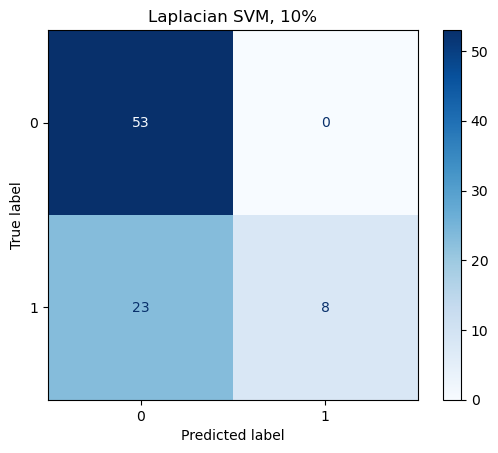

In [81]:
best_model10 = LabelSpreading(
    kernel='rbf',
    gamma=mejor10_lap["gamma"],
    alpha=mejor10_lap["alpha"]
)

best_model10.fit(X_train, y20train)

y_pred_best10 = best_model10.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best10)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Laplacian SVM, 10%")
plt.show()

Se encuentra que este modelo presenta características similares a las del anterior, aunque el f1 es menor por 4% aproximadamente. De igual manera, se tiene un visible sesgo respecto a los errores, siendo los falsos positivos aquellos que son más recurrentes.

#### Para el 20%

In [82]:
resultados20_lap = []

for gamma in gamma_values:
    for alpha in alpha_values:
        
        modelo20_lap = LabelSpreading(
            kernel='rbf',
            gamma=gamma,
            alpha=alpha,
            max_iter=100
        )
        
        modelo20_lap.fit(X_train, y20train)
        
        ypred20_lap = modelo20_lap.predict(X_test)
        
        acc = accuracy_score(y_test, ypred20_lap)
        f1 = f1_score(y_test, ypred20_lap)
        
        resultados20_lap.append({
            "gamma": gamma,
            "alpha": alpha,
            "accuracy": acc,
            "f1": f1
        })

df_resultados20_lap = pd.DataFrame(resultados20_lap)

In [83]:
df_resultados20_lap

,gamma,alpha,accuracy,f1
0,0.01,0.2,0.630952,0.000000
1,0.01,0.5,0.630952,0.000000
2,0.01,0.8,0.630952,0.000000
3,0.10,0.2,0.630952,0.000000
4,0.10,0.5,0.630952,0.000000
5,0.10,0.8,0.630952,0.000000
6,1.00,0.2,0.738095,0.541667
7,1.00,0.5,0.738095,0.521739
8,1.00,0.8,0.726190,0.410256


In [84]:
mejor20_lap = df_resultados20_lap.loc[
    (
        0.7 * df_resultados20_lap["f1"] +
        0.3 * df_resultados20_lap["accuracy"]
    ).idxmax()
]

print(mejor20_lap)

gamma       1.000000
alpha       0.200000
accuracy    0.738095
f1          0.541667
Name: 6, dtype: float64


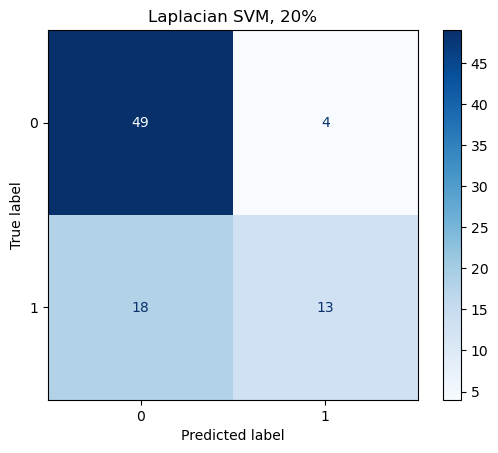

In [85]:
best_model20 = LabelSpreading(
    kernel='rbf',
    gamma=mejor20_lap["gamma"],
    alpha=mejor20_lap["alpha"]
)

best_model20.fit(X_train, y20train)

y_pred_best20 = best_model20.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best20)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.title("Laplacian SVM, 20%")
plt.show()

Se tiene que el valor del f1 es el menor de los modelos laplacianos implementados, siendo su valor muy cercano al azar, siendo solo un 4% mayor que este. Su precisión (accuracy) también es el más bajo a comparación a los otros, aunque solo por 5%. La distribución de los valores de las predicciones es muy similar a los de los laplacianos anteriores.

## Visualizaciones

### Curvas de desempeño vs % de Etiquetas

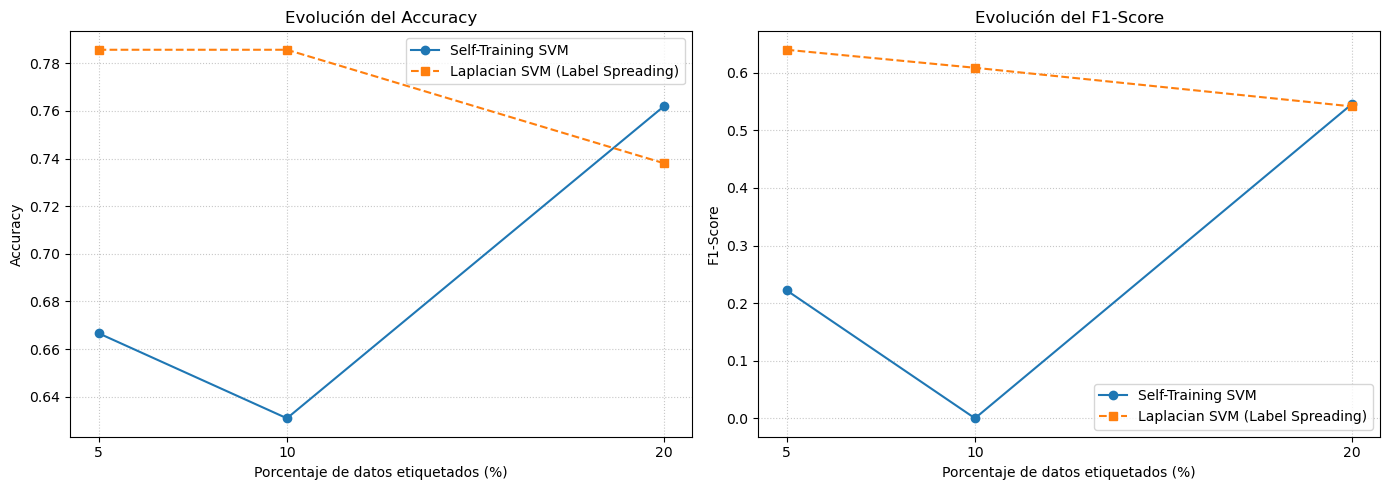

In [86]:
# Porcentajes evaluados
porcentajes = [5, 10, 20]

# Extrayendo métricas de los mejores modelos de Self-Training
acc_st = [mejor5['accuracy'], mejor10['accuracy'], mejor20['accuracy']]
f1_st = [mejor5['f1'], mejor10['f1'], mejor20['f1']]

# Extrayendo métricas de los mejores modelos de Label Spreading
acc_ls = [mejor5_lap['accuracy'], mejor10_lap['accuracy'], mejor20_lap['accuracy']]
f1_ls = [mejor5_lap['f1'], mejor10_lap['f1'], mejor20_lap['f1']]

# Creación del gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Accuracy
ax1.plot(porcentajes, acc_st, marker='o', linestyle='-', label='Self-Training SVM')
ax1.plot(porcentajes, acc_ls, marker='s', linestyle='--', label='Laplacian SVM (Label Spreading)')
ax1.set_title('Evolución del Accuracy')
ax1.set_xlabel('Porcentaje de datos etiquetados (%)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(porcentajes)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# Gráfico de F1-Score
ax2.plot(porcentajes, f1_st, marker='o', linestyle='-', label='Self-Training SVM')
ax2.plot(porcentajes, f1_ls, marker='s', linestyle='--', label='Laplacian SVM (Label Spreading)')
ax2.set_title('Evolución del F1-Score')
ax2.set_xlabel('Porcentaje de datos etiquetados (%)')
ax2.set_ylabel('F1-Score')
ax2.set_xticks(porcentajes)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Matrices de Confusión Consolidadas

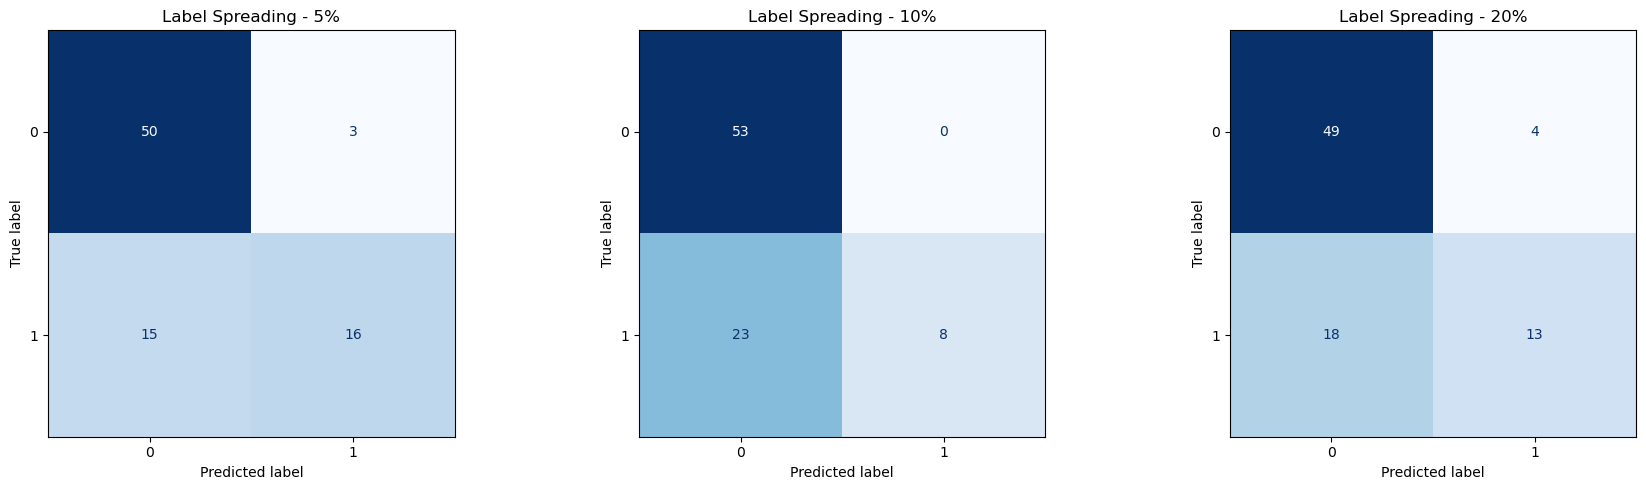

In [90]:
# Para este gráfico, asumimos que ya tienes y_pred_best5, y_pred_best10, y_pred_best20 de Label Spreading
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [
    (y_test, y_pred_best5, "Label Spreading - 5%"),
    (y_test, y_pred_best10, "Label Spreading - 10%"), # Usando tu variable actual del 10%
    (y_test, y_pred_best20, "Label Spreading - 20%")
]

for ax, (y_true, y_pred, title) in zip(axes, matrices):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Visualización: Predicción vs Valor Real (Usando PCA)

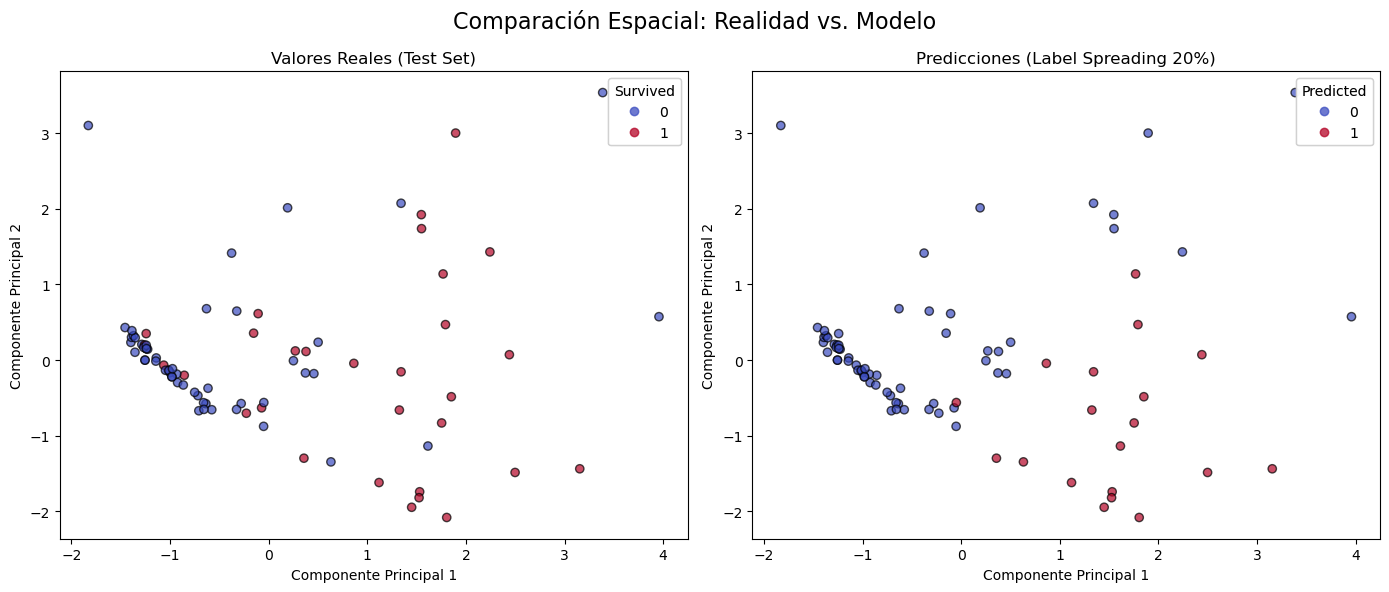

In [91]:
# Reducimos X_test a 2 dimensiones para graficar
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Compararemos el valor real vs el mejor modelo de 20% (Label Spreading)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Valores Reales
scatter1 = ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.7)
ax1.set_title('Valores Reales (Test Set)')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')
legend1 = ax1.legend(*scatter1.legend_elements(), title="Survived")
ax1.add_artist(legend1)

# Gráfico 2: Predicciones del modelo 20% Label Spreading
scatter2 = ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_best5, cmap='coolwarm', edgecolors='k', alpha=0.7)
ax2.set_title('Predicciones (Label Spreading 20%)')
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')
legend2 = ax2.legend(*scatter2.legend_elements(), title="Predicted")
ax2.add_artist(legend2)

plt.suptitle('Comparación Espacial: Realidad vs. Modelo', fontsize=16)
plt.tight_layout()
plt.show()

### Distribución de la Confianza (Certeza del modelo)

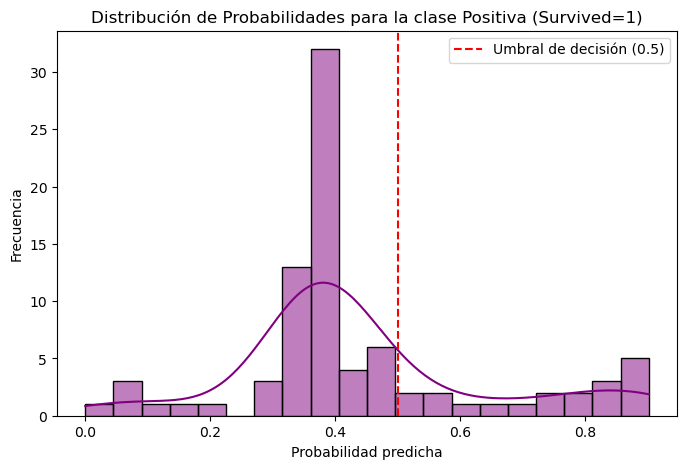

In [92]:
# Obteniendo las probabilidades del modelo de Label Spreading (20%)
probas = best_model5.predict_proba(X_test)

plt.figure(figsize=(8, 5))
sns.histplot(probas[:, 1], bins=20, kde=True, color='purple')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral de decisión (0.5)')
plt.title('Distribución de Probabilidades para la clase Positiva (Survived=1)')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()